# Fase 2: auditoria frontal y calibracion ergonomica

Esta libreta no repite la inferencia de pose. Trabaja sobre la corrida larga ya guardada
para responder tres preguntas:

- que partes del cuerpo estan realmente visibles en el encuadre frontal de webcam
- que contradicciones hay entre las etiquetas del dataset y la salida del motor de reglas
- que umbrales conviene revisar antes de pasar al siguiente paso del proyecto

El foco es el caso de uso realista de webcam frontal. La linea lateral queda recogida
como extension futura o validacion complementaria, no como bloqueo del MVP frontal.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.3f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")

PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
SRC_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/src


In [2]:
from ergonomics import (
    DATASET_CATALOG,
    DEFAULT_AUDIT_LANDMARKS,
    build_component_status_summary,
    build_keypoint_visibility_summary,
    build_label_status_matrix,
    build_reference_threshold_candidates,
    load_run_audit_tables,
    plot_keypoint_coverage_heatmap,
    plot_pose_gallery,
    plot_status_by_group,
    plot_status_distribution,
    select_audit_examples,
    summarize_available_datasets,
)

## 1. Configuracion de auditoria

Partimos de la corrida larga ya completada sobre el dataset frontal base.
Todo el analisis posterior sale de los CSV guardados en disco.

In [3]:
RUN_LABEL = "posture_correction_v4_full_dataset_v1"
VISIBILITY_THRESHOLD = 0.35
REFERENCE_GROUP = "looks good"
TARGET_DATASET_KEY = "posture_correction_v4_folder_v1"

target_spec = DATASET_CATALOG[TARGET_DATASET_KEY]
display(
    Markdown(
        f"""
**Contexto de auditoria**

- Run label: `{RUN_LABEL}`
- Dataset base: `{TARGET_DATASET_KEY}`
- Descripcion: `{target_spec.notes}`
- Threshold de visibilidad: `{VISIBILITY_THRESHOLD}`
- Grupo de referencia para calibracion: `{REFERENCE_GROUP}`
"""
    )
)


**Contexto de auditoria**

- Run label: `posture_correction_v4_full_dataset_v1`
- Dataset base: `posture_correction_v4_folder_v1`
- Descripcion: `Webcam frontal. Es el dataset mas cercano al caso real del proyecto.`
- Threshold de visibilidad: `0.35`
- Grupo de referencia para calibracion: `looks good`


## 2. Carga de artefactos

Cargamos la manifest, los landmarks estimados y el analisis ergonomico ya calculado.
La tabla fusionada sirve para auditar casos concretos con overlay y metricas.

In [4]:
run_tables = load_run_audit_tables(RUN_LABEL)
manifest_df = run_tables.manifest_df
pose_df = run_tables.pose_df
analysis_df = run_tables.analysis_df
audit_df = run_tables.merged_df

display(
    pd.DataFrame(
        [
            {"item": "Run dir", "value": str(run_tables.run_dir)},
            {"item": "Imagenes en manifest", "value": len(manifest_df)},
            {"item": "Filas pose", "value": len(pose_df)},
            {"item": "Filas analisis", "value": len(analysis_df)},
            {"item": "Filas fusionadas", "value": len(audit_df)},
        ]
    )
)

display(analysis_df.head(5))

,item,value
0,Run dir,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...
1,Imagenes en manifest,4666
2,Filas pose,4666
3,Filas analisis,4666
4,Filas fusionadas,4666


,image_path,image_name,group,split,pose_detected,shoulder_width,shoulder_tilt_deg,shoulder_height_diff_ratio,trunk_tilt_deg,head_lateral_offset_ratio,neck_tilt_deg,left_elbow_angle_deg,right_elbow_angle_deg,shoulder_tilt_status,shoulder_height_status,shoulder_status,trunk_status,head_offset_status,neck_tilt_status,head_status,left_elbow_status,right_elbow_status,overall_status,feedback
0,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,extract0757_jpg.rf.649d916c13f9ada6c3413d45411...,looks good,test,True,0.441,11.946,0.207,NaN,0.115,7.738,NaN,NaN,risk,risk,risk,insufficient_data,improvable,adequate,improvable,insufficient_data,insufficient_data,risk,Recoloca la cabeza sobre el eje de los hombros...
1,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,extract0876_jpg.rf.2598747659f819876775cd9932f...,looks good,test,True,0.396,3.278,0.057,NaN,0.032,2.173,NaN,NaN,adequate,improvable,improvable,insufficient_data,adequate,adequate,adequate,insufficient_data,insufficient_data,improvable,Intenta mantener los hombros mas nivelados y r...
2,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,extract0877_jpg.rf.ddf5603aec4c2f244208dce9fd6...,looks good,test,True,0.395,1.890,0.033,NaN,0.020,1.366,NaN,NaN,adequate,improvable,improvable,insufficient_data,adequate,adequate,adequate,insufficient_data,insufficient_data,improvable,Intenta mantener los hombros mas nivelados y r...
3,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,extract0878_jpg.rf.06e745794cc44ebaaa2033094d7...,looks good,test,True,0.393,0.866,0.015,NaN,0.030,1.994,NaN,NaN,adequate,adequate,adequate,insufficient_data,adequate,adequate,adequate,insufficient_data,insufficient_data,adequate,Sin alertas principales en esta primera revision.
4,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,extract0879_jpg.rf.f944c729e46feef1d6039dccad5...,looks good,test,True,0.375,3.679,0.064,NaN,0.014,0.924,NaN,NaN,adequate,improvable,improvable,insufficient_data,adequate,adequate,adequate,insufficient_data,insufficient_data,improvable,Intenta mantener los hombros mas nivelados y r...


## 3. Lectura ejecutiva

Antes de entrar al detalle visual, conviene dejar clara la situacion global.
Aqui vemos la distribucion del estado ergonomico y donde chocan mas las etiquetas del dataset
con la clasificacion actual del motor de reglas.

,overall_status,image_count,share_pct
0,risk,2696,57.780
1,improvable,1181,25.311
2,adequate,782,16.760
3,insufficient_data,7,0.150


overall_status,group,adequate,improvable,insufficient_data,risk
0,looks good,22.534,35.656,0.000,41.810
1,sit up straight,16.539,23.657,0.298,59.506
2,straighten head,11.934,19.095,0.000,68.971


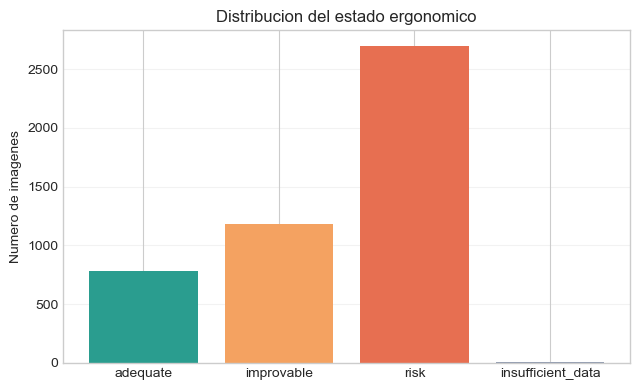

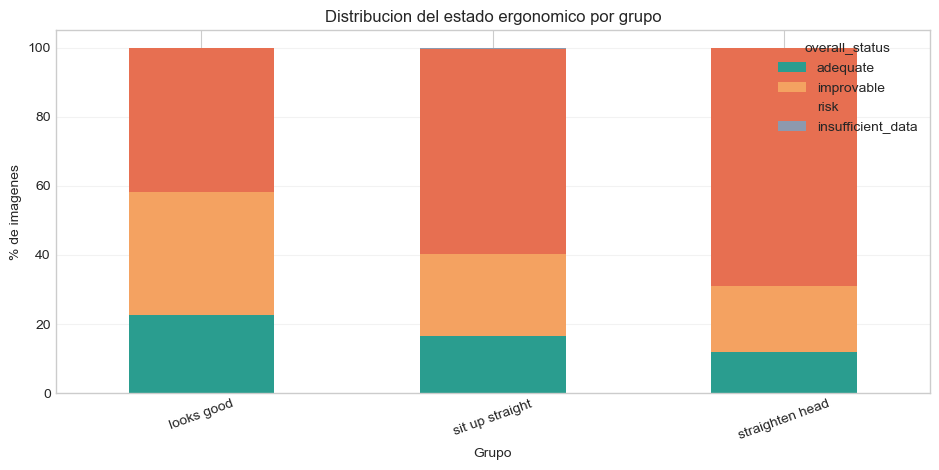

In [5]:
status_summary_df = (
    analysis_df["overall_status"]
    .value_counts()
    .rename_axis("overall_status")
    .reset_index(name="image_count")
)
status_summary_df["share_pct"] = status_summary_df["image_count"] / status_summary_df["image_count"].sum() * 100.0

label_status_matrix_df = build_label_status_matrix(analysis_df, normalize=True)

display(status_summary_df)
display(label_status_matrix_df)

fig, ax = plot_status_distribution(analysis_df)
plt.show()

fig, ax = plot_status_by_group(analysis_df, normalize=True)
plt.show()

## 4. Limites reales del encuadre frontal

Esta es la primera comprobacion importante del notebook.
Si determinadas partes del cuerpo casi nunca aparecen, no tiene sentido darles mucho peso
en la clasificacion frontal.

,landmark,visible_images,total_images,visibility_pct
2,left_shoulder,4659,4666,99.850
7,right_shoulder,4659,4666,99.850
4,nose,4659,4666,99.850
5,right_elbow,2911,4666,62.387
0,left_elbow,2349,4666,50.343
8,right_wrist,405,4666,8.680
3,left_wrist,381,4666,8.165
6,right_hip,11,4666,0.236
1,left_hip,7,4666,0.150


group,looks good,sit up straight,straighten head
landmark,,,
left_elbow,43.982,49.233,58.272
left_hip,0.000,0.256,0.082
left_shoulder,100.000,99.702,100.000
left_wrist,5.701,6.607,13.416
nose,100.000,99.702,100.000
right_elbow,64.977,60.315,64.033
right_hip,0.271,0.298,0.082
right_shoulder,100.000,99.702,100.000
right_wrist,7.059,7.928,11.605


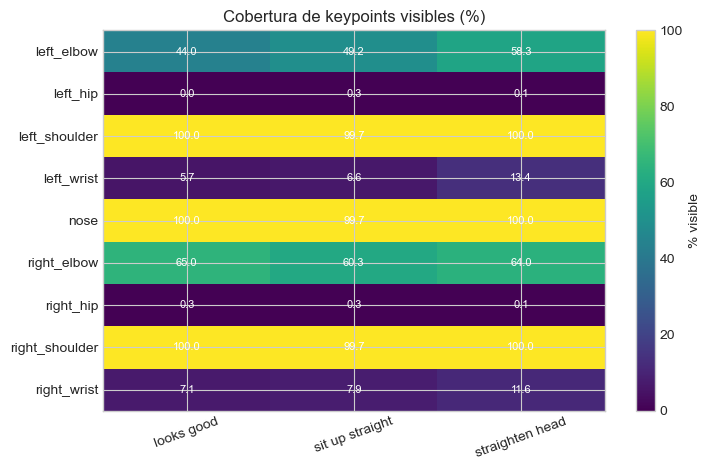

In [6]:
coverage_by_group_df = build_keypoint_visibility_summary(
    pose_df,
    landmarks=DEFAULT_AUDIT_LANDMARKS,
    visibility_threshold=VISIBILITY_THRESHOLD,
    group_col="group",
)

coverage_overall_df = build_keypoint_visibility_summary(
    pose_df,
    landmarks=DEFAULT_AUDIT_LANDMARKS,
    visibility_threshold=VISIBILITY_THRESHOLD,
    group_col=None,
)

coverage_pivot_df = (
    coverage_by_group_df.pivot(index="landmark", columns="group", values="visibility_pct")
    .sort_index()
)

display(coverage_overall_df.sort_values("visibility_pct", ascending=False))
display(coverage_pivot_df)

fig, ax = plot_keypoint_coverage_heatmap(coverage_by_group_df, group_col="group")
plt.show()

## 5. Que componentes estan dominando el error

El objetivo aqui es ver si el problema viene sobre todo de cabeza, hombros, tronco o brazos.
Con eso podemos decidir que parte del motor de reglas merece recalibracion inmediata y que parte
debe quedar como secundaria o directamente fuera del alcance frontal.

In [7]:
component_summary_df = build_component_status_summary(
    analysis_df,
    group_col="group",
    normalize=True,
)

component_risk_view_df = (
    component_summary_df[component_summary_df["status"].isin(["risk", "improvable", "insufficient_data"])]
    .pivot(index="component", columns=["group", "status"], values="share_pct")
    .fillna(0.0)
    .sort_index()
)

display(component_summary_df.head(24))
display(component_risk_view_df)

,component,status,image_count,share_pct,group
0,head_status,adequate,1049,94.932,looks good
1,head_status,improvable,54,4.887,looks good
2,head_status,risk,2,0.181,looks good
3,left_elbow_status,adequate,3,0.271,looks good
4,left_elbow_status,insufficient_data,1042,94.299,looks good
5,left_elbow_status,risk,60,5.430,looks good
6,overall_status,adequate,249,22.534,looks good
7,overall_status,improvable,394,35.656,looks good
8,overall_status,risk,462,41.810,looks good
9,right_elbow_status,adequate,3,0.271,looks good


group              looks good                          sit up straight  \
status             improvable   risk insufficient_data      improvable   
component                                                                
head_status             4.887  0.181             0.000          17.093   
left_elbow_status       0.000  5.430            94.299           0.171   
overall_status         35.656 41.810             0.000          23.657   
right_elbow_status      0.543  5.701            93.484           0.469   
shoulder_status        36.652 36.742             0.000          26.641   
trunk_status            0.000  0.000           100.000           0.000   

group                                       straighten head         \
status             insufficient_data   risk      improvable   risk   
component                                                            
head_status                    0.298 16.070          23.539 25.103   
left_elbow_status             93.521  5.925           0.329 12.099   
overall_status                 0.298 59.506          19.095 68.971   
right_elbow_status            92.455  6.735           0.988  9.712   
shoulder_status                0.298 48.210          22.798 57.449   
trunk_status                  99.829  0.000           0.000  0.000   

group                                 
status             insufficient_data  
component                             
head_status                    0.000  
left_elbow_status             87.407  
overall_status                 0.000  
right_elbow_status            88.642  
shoulder_status                0.000  
trunk_status                  99.918

## 6. Calibracion preliminar de umbrales con el grupo `looks good`

Aqui comparamos los umbrales actuales con percentiles del grupo que el dataset considera
visualmente aceptable. No se trata de cambiar reglas a ciegas, sino de localizar donde
el motor esta claramente desalineado con la semantica del dataset frontal.

In [8]:
threshold_candidates_df = build_reference_threshold_candidates(
    analysis_df,
    reference_group=REFERENCE_GROUP,
    adequate_quantile=0.75,
    improvable_quantile=0.90,
)

threshold_review_df = threshold_candidates_df.copy()
threshold_review_df["observacion"] = [
    "alineado" if metric == "shoulder_tilt_deg"
    else "demasiado estricto en frontal" if metric == "shoulder_height_diff_ratio"
    else "demasiado permisivo en frontal" if metric in {"head_lateral_offset_ratio", "neck_tilt_deg"}
    else "sin soporte suficiente en frontal"
    for metric in threshold_review_df["metric"]
]

display(threshold_review_df)

,metric,reference_group,non_null_count,current_adequate_max,current_improvable_max,candidate_adequate_max,candidate_improvable_max,reference_mean,reference_median,observacion
0,head_lateral_offset_ratio,looks good,1105,0.080,0.160,0.047,0.066,0.034,0.030,demasiado permisivo en frontal
1,neck_tilt_deg,looks good,1105,8.000,15.000,3.116,4.328,2.271,2.013,demasiado permisivo en frontal
2,shoulder_height_diff_ratio,looks good,1105,0.030,0.070,0.085,0.112,0.059,0.055,demasiado estricto en frontal
3,shoulder_tilt_deg,looks good,1105,5.000,10.000,4.874,6.425,3.403,3.178,alineado


## 7. Casos a revisar visualmente

Esta seccion es la mas util para discutir con criterio si el problema esta en la etiqueta,
en la geometria del encuadre o en el umbral actual.

,image_name,group,overall_status,shoulder_height_diff_ratio,shoulder_tilt_deg,head_lateral_offset_ratio,neck_tilt_deg
0,mb20124_jpg.rf.9931b58d74a91ef3ac0bf9757fca929...,looks good,risk,0.225,13.016,0.041,2.758
1,extract0757_jpg.rf.649d916c13f9ada6c3413d45411...,looks good,risk,0.207,11.946,0.115,7.738
2,extract1457_jpg.rf.879574c99489fa25b9fec567270...,looks good,risk,0.205,11.857,0.020,1.567
3,mb20287_jpg.rf.88c6a7b8e526e3a3a681aeebc339a98...,looks good,risk,0.195,11.258,0.027,1.791
4,extract1724_jpg.rf.6ec10efd20886730f0acd07d761...,looks good,risk,0.174,10.041,0.029,1.857
5,extract1731_jpg.rf.d53cf650b662249b0c332d7aefc...,looks good,risk,0.169,9.754,0.004,0.269


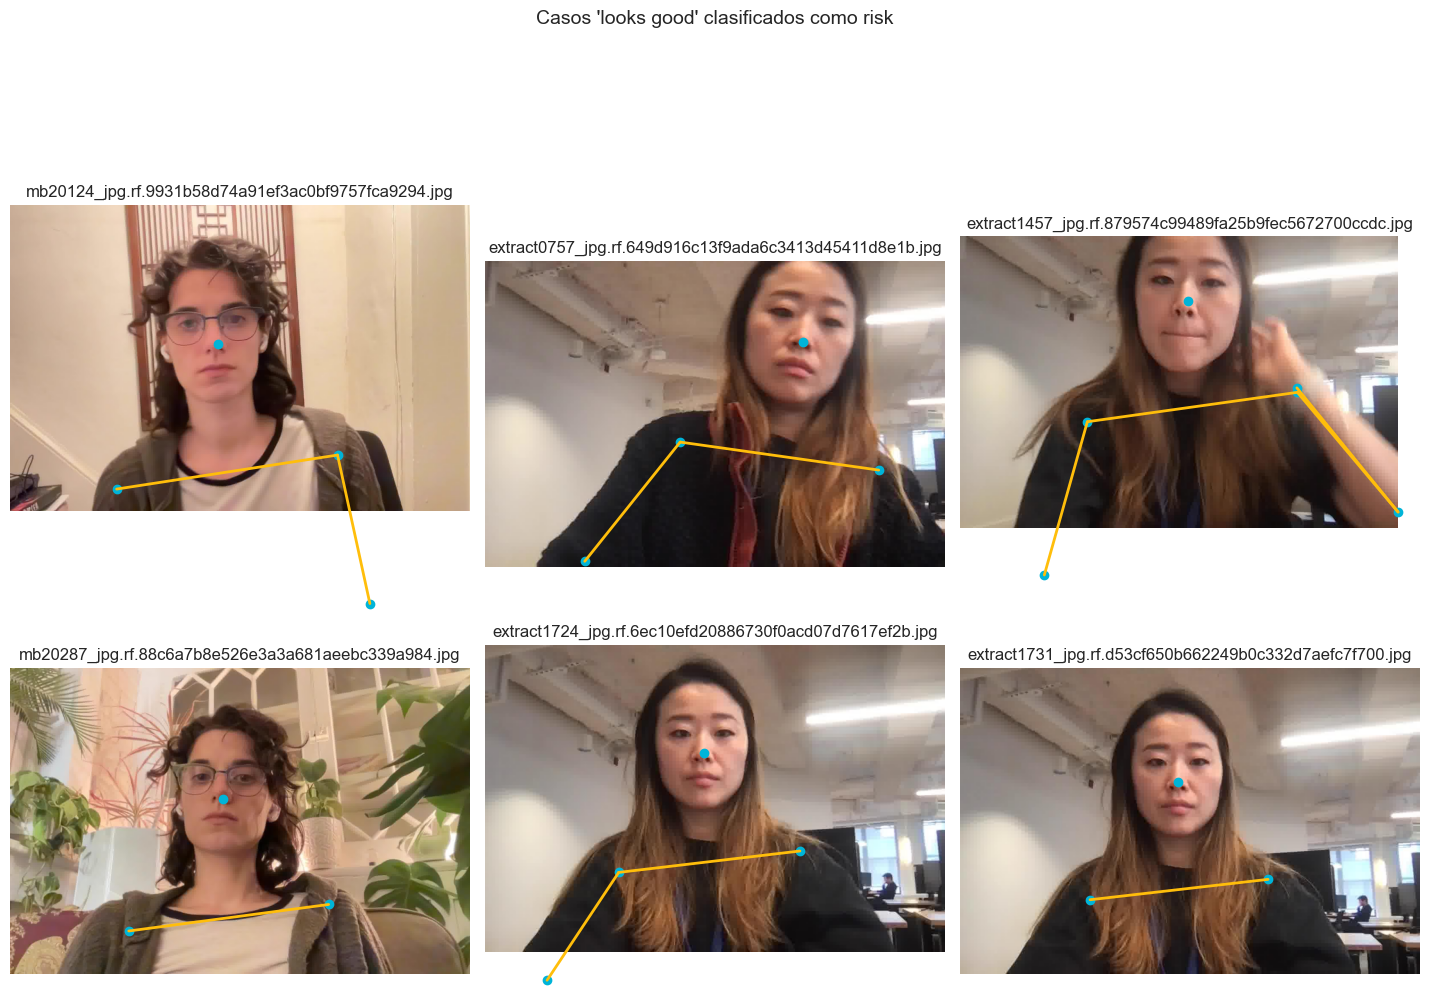

In [9]:
looks_good_risk_df = select_audit_examples(
    audit_df,
    filters={"group": "looks good", "overall_status": "risk"},
    sort_by=["shoulder_height_diff_ratio", "head_lateral_offset_ratio"],
    ascending=[False, False],
    limit=6,
)

display(
    looks_good_risk_df[
        [
            "image_name",
            "group",
            "overall_status",
            "shoulder_height_diff_ratio",
            "shoulder_tilt_deg",
            "head_lateral_offset_ratio",
            "neck_tilt_deg",
        ]
    ]
)

fig, axes = plot_pose_gallery(
    looks_good_risk_df,
    caption_fields=[
        "overall_status",
        "shoulder_height_diff_ratio",
        "shoulder_tilt_deg",
        "head_lateral_offset_ratio",
        "neck_tilt_deg",
    ],
    title="Casos 'looks good' clasificados como risk",
    ncols=3,
)
plt.show()

,image_name,group,overall_status,shoulder_height_diff_ratio,head_lateral_offset_ratio,neck_tilt_deg
0,extract0138_jpg.rf.113352ac2023d5321c8f1b46c84...,straighten head,adequate,0.030,0.000,0.031
1,mb20007_jpg.rf.a4b04fb1aaafb9eb5c3d40464dfb667...,straighten head,adequate,0.010,0.001,0.057
2,extract3593_jpg.rf.282bc5bb8b52a4c4b6949e567e4...,straighten head,adequate,0.027,0.001,0.056
3,mb0200_jpg.rf.ee8d94852558e9fbed7455d2c31b9eec...,straighten head,adequate,0.008,0.001,0.103
4,extract0448_jpg.rf.773e2af3231d78ec0edc738ce57...,straighten head,adequate,0.018,0.001,0.072
5,mb0197_jpg.rf.af9535401de9eee07ae97845a2a39c0d...,straighten head,adequate,0.030,0.002,0.216


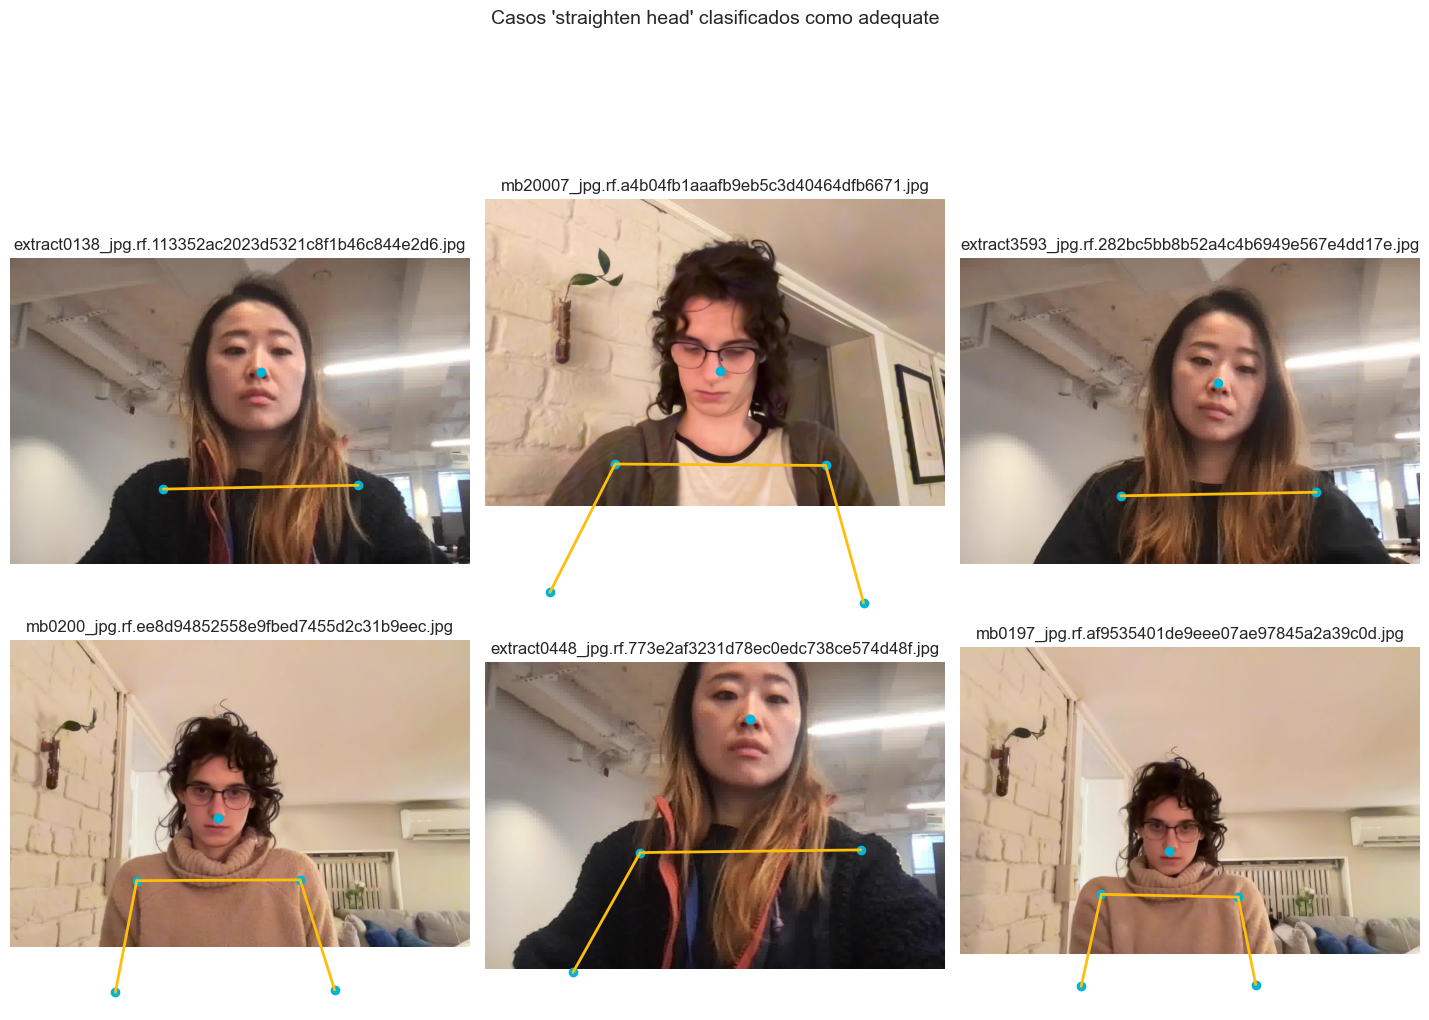

In [10]:
straighten_head_adequate_df = select_audit_examples(
    audit_df,
    filters={"group": "straighten head", "overall_status": "adequate"},
    sort_by=["head_lateral_offset_ratio", "neck_tilt_deg"],
    ascending=[True, True],
    limit=6,
)

display(
    straighten_head_adequate_df[
        [
            "image_name",
            "group",
            "overall_status",
            "shoulder_height_diff_ratio",
            "head_lateral_offset_ratio",
            "neck_tilt_deg",
        ]
    ]
)

fig, axes = plot_pose_gallery(
    straighten_head_adequate_df,
    caption_fields=[
        "overall_status",
        "head_lateral_offset_ratio",
        "neck_tilt_deg",
        "shoulder_height_diff_ratio",
    ],
    title="Casos 'straighten head' clasificados como adequate",
    ncols=3,
)
plt.show()

,image_name,group,overall_status,shoulder_height_diff_ratio,head_lateral_offset_ratio,neck_tilt_deg,left_wrist_visibility,right_wrist_visibility
0,extract0445_jpg.rf.0c7f2711ec3333ac0849b0625d4...,sit up straight,adequate,0.000,0.011,0.707,0.180,0.044
1,extract0939_jpg.rf.dd6df4e3426a24bb9b75585e5f7...,sit up straight,adequate,0.000,0.001,0.099,0.026,0.019
2,extract3222_jpg.rf.c6a0e8147f2be023ba786cad626...,sit up straight,improvable,0.070,0.072,4.367,0.018,0.052
3,extract3161_jpg.rf.2b11394e5a982ee026dff4d90b0...,sit up straight,improvable,0.070,0.024,1.753,0.120,0.029
4,mb20294_jpg.rf.04454e4acffdd70746b8b8d08c1ed3f...,sit up straight,risk,0.399,0.242,21.210,0.033,0.028
5,mb20296_jpg.rf.c1f293e0086260c49cbb40692dd023e...,sit up straight,risk,0.380,0.153,14.073,0.077,0.037


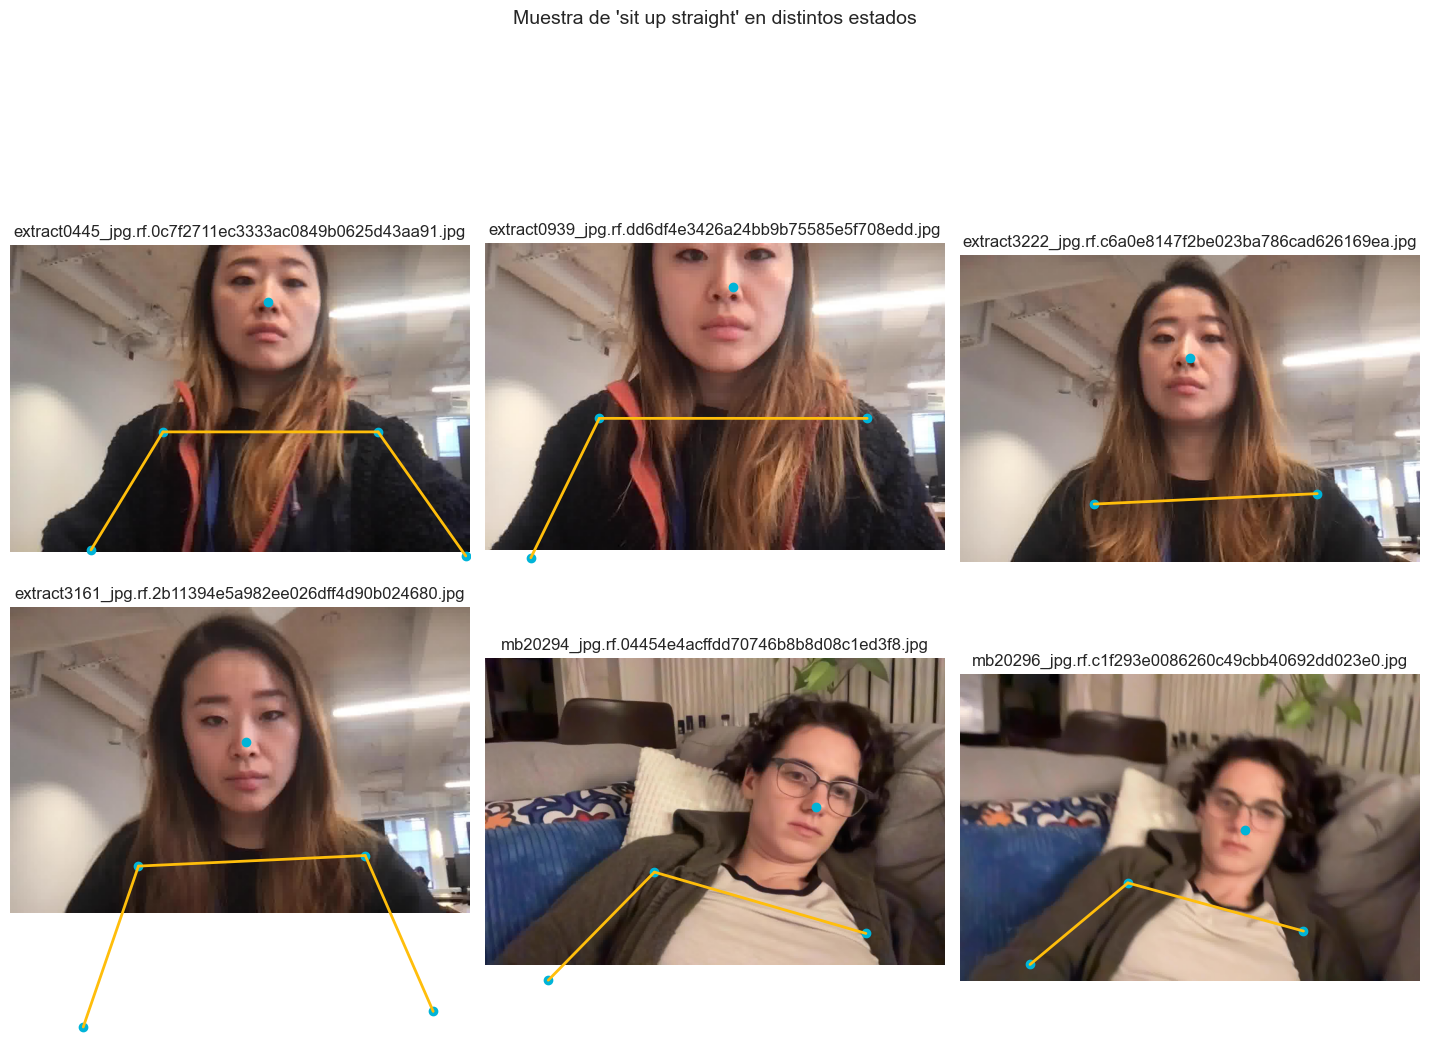

In [ ]:
sit_up_straight_audit_df = pd.concat(
    [
        select_audit_examples(
            audit_df,
            filters={"group": "sit up straight", "overall_status": status_name},
            sort_by=["shoulder_height_diff_ratio", "head_lateral_offset_ratio"],
            ascending=[status_name == "adequate", status_name == "adequate"],
            limit=2,
        )
        for status_name in ["adequate", "improvable", "risk"]
    ],
    ignore_index=True,
)

display(
    sit_up_straight_audit_df[
        [
            "image_name",
            "group",
            "overall_status",
            "shoulder_height_diff_ratio",
            "head_lateral_offset_ratio",
            "neck_tilt_deg",
            "left_wrist_visibility",
            "right_wrist_visibility",
        ]
    ]
)

fig, axes = plot_pose_gallery(
    sit_up_straight_audit_df,
    caption_fields=[
        "overall_status",
        "shoulder_height_diff_ratio",
        "head_lateral_offset_ratio",
        "neck_tilt_deg",
    ],
    title="Muestra de 'sit up straight' en distintos estados",
    ncols=3,
)
plt.show()

## 8. Linea lateral como extension del proyecto

El frontal sigue siendo el MVP mas realista para oficina y teletrabajo. Aun asi, la documentacion
del proyecto ya planteaba una camara lateral como opcion para medir mejor la espalda y la cabeza adelantada.
Aqui dejamos identificados los datasets que mejor encajan con esa extension.

In [12]:
available_datasets_df = summarize_available_datasets()
lateral_candidates_df = available_datasets_df[
    available_datasets_df["dataset_key"].isin(["sitting_posture_4keypoint", "desk_posture_coco_v1"])
].copy()

display(
    lateral_candidates_df[
        ["dataset_key", "label", "format", "total_images", "group_count", "notes"]
    ]
)

,dataset_key,label,format,total_images,group_count,notes
3,sitting_posture_4keypoint,Sitting Posture 4 keypoint,coco,655,3,Mayormente lateral. Buen punto de partida para...
4,desk_posture_coco_v1,Desk Posture coco,coco,148,3,"Dataset pequeno con pose etiquetada, util para..."


## 9. Decision operativa

Esta libreta deja una conclusion clara para la siguiente iteracion:

- el MVP frontal tiene sentido para cabeza lateral, cuello lateral y simetria de hombros
- `trunk_status` no debe pesar en frontal porque casi nunca hay caderas visibles
- el angulo completo de codo tampoco debe pesar demasiado mientras muñecas y antebrazos queden fuera
- `shoulder_height_diff_ratio` esta castigando demasiado al grupo `looks good`
- `head_lateral_offset_ratio` y `neck_tilt_deg` parecen mas permisivos de lo que sugiere el dataset
- la medicion de cabeza adelantada debe quedar para la linea lateral

In [13]:
insights_md = f"""
**Lectura final de la auditoria**

- El dataset frontal base tiene `{len(analysis_df)}` imagenes auditadas.
- La clase `looks good` sigue cayendo en `risk` un `{label_status_matrix_df.loc[label_status_matrix_df['group'] == 'looks good', 'risk'].iloc[0]:.1f}%`.
- Las caderas solo son visibles en torno al `{coverage_overall_df.loc[coverage_overall_df['landmark'] == 'left_hip', 'visibility_pct'].iloc[0]:.1f}%` y `{coverage_overall_df.loc[coverage_overall_df['landmark'] == 'right_hip', 'visibility_pct'].iloc[0]:.1f}%` de las imagenes.
- Las muñecas aparecen en torno al `{coverage_overall_df.loc[coverage_overall_df['landmark'] == 'left_wrist', 'visibility_pct'].iloc[0]:.1f}%` y `{coverage_overall_df.loc[coverage_overall_df['landmark'] == 'right_wrist', 'visibility_pct'].iloc[0]:.1f}%`.
- El mejor siguiente paso ya no es comparar mas modelos, sino recalibrar el motor de reglas para el caso frontal.
"""

display(Markdown(insights_md))


**Lectura final de la auditoria**

- El dataset frontal base tiene `4666` imagenes auditadas.
- La clase `looks good` sigue cayendo en `risk` un `41.8%`.
- Las caderas solo son visibles en torno al `0.2%` y `0.2%` de las imagenes.
- Las muñecas aparecen en torno al `8.2%` y `8.7%`.
- El mejor siguiente paso ya no es comparar mas modelos, sino recalibrar el motor de reglas para el caso frontal.
